In [60]:
import numpy as np
from plotting_utils import plot_correlation_on_flatmap
from pathlib import Path

import sys

In [ ]:
baseline = np.load('../outputs/results/subject07_listening_baseline.npz')
peaks = np.load('../outputs/results/subject07_listening_peak.npz')
valleys = np.load('../outputs/results/subject07_listening_valley.npz')
random = np.load('../outputs/results/subject07_listening_random.npz')
english1000 = np.load('../outputs/results/subject07_listening_english1000.npz')

In [ ]:
def contrast_maps(data_1, data_2):
    contrast = {}
    for key in ['r','r2', 'r_sig', 'score']:
        contrast[key] = data_1[key] - data_2[key]
    return contrast

In [ ]:
contrast = contrast_maps(baseline,english1000)

In [ ]:
np.nansum(contrast['r_sig'])

In [22]:
%load_ext autoreload
%autoreload 2
import matplotlib.pyplot as plt
import pandas as pd
import sys
sys.path.append('../')
from data_loading import file_io, config
import os
from load_data_sequences import create_data_sequences, load_trfiles, load_textgrids

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [16]:
story6 = create_data_sequences(['story_06'], os.path.join('..',config.DEFAULT_TRFILE_PATH), os.path.join('..',config.DEFAULT_TEXTGRID_PATH), os.path.join('..',config.DEFAULT_DATASEQ_PATH))

Loading TR files... ✓
Loading TextGrid textgrids... 

Loading TextGrid textgrids: 100%|██████████| 1/1 [00:00<00:00, 120.08it/s]


[0.05238095238095, 0.0922902494331, 0.18707482993205, 0.426530612245, 0.6609977324265, 0.935374149662, 1.29455782313, 1.52902494331, 1.643764172335, 1.88820861678, 2.27233560091, 2.586621315195, 2.77619047619, 2.930839002265, 3.0555555555550002, 3.150340136055, 3.33990929705, 3.67414965986, 3.948526077095, 4.088208616779999, 4.197959183675, 4.3126984127, 4.502267573695001, 4.81156462585, 5.16575963719, 5.46507936508, 5.639682539680001, 5.93900226757, 6.303174603175, 6.527664399095, 6.662358276645, 6.797052154195001, 6.991609977325, 7.1761904761899995, 7.420634920635, 7.650113378685, 7.90952380952, 8.10408163265, 8.168934240359999, 8.29863945578, 8.702721088435, 9.34126984127, 9.924943310675001, 10.3090702948, 10.73310657595, 11.0573696145, 11.1022675737, 11.20204081635, 11.351700680299999, 11.596145124749999, 12.025170068049999, 12.7684807256, 13.37709750565, 13.616553287999999, 14.03339231482745, 14.359063520272977, 14.525409316033437, 14.773879611801686, 14.998858054513775, 15.138095

Creating DataSequences: 100%|██████████| 1/1 [00:00<00:00, 31.03it/s]

[5.2000e-02 9.2000e-02 1.8650e-01 ... 7.2780e+02 7.2795e+02 7.3245e+02]

  Example ('story_06'):
    Words: 2786
    TRs: 373
    Bad words removed: 596
    First 10 words: ['i', 'grew', 'up', 'a', 'uh', 'a', 'huge', 'fan', 'of', 'of']


In [35]:
tr = load_trfiles(config.STORIES, os.path.join('..',config.DEFAULT_TRFILE_PATH))
tg = load_textgrids(config.STORIES, os.path.join('..',config.DEFAULT_TEXTGRID_PATH))

Loading TextGrid textgrids: 100%|██████████| 11/11 [00:00<00:00, 57.24it/s]


In [83]:
for story in config.STORIES[:-1]:
    print(file_io.load_features('trn', os.path.join('..',config.DEFAULT_FEATURE_PATH))[story]['english1000'].shape[0])
    print(len(tr[story].trtimes))

358
358


382
382


369
369


415
415


445
445


373
373


437
437


419
419


370
370


319
319


In [46]:
tr_last = [tr[story].trtimes[-1] for story in config.STORIES]

In [54]:
tg_last = [tg[story][-1][1] for story in config.STORIES]

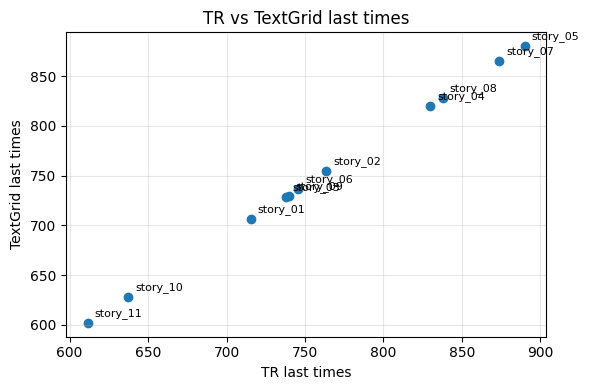

In [57]:
plt.figure(figsize=(6, 4))
plt.scatter(tr_last, tg_last)
for i, story in enumerate(config.STORIES):
    plt.annotate(story, (tr_last[i], tg_last[i]), xytext=(5, 5),
                 textcoords='offset points', fontsize=8)
plt.xlabel("TR last times")
plt.ylabel("TextGrid last times")
plt.title("TR vs TextGrid last times")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [179]:
ds = file_io.load_dataseqs(os.path.join('..',config.DEFAULT_DATASEQ_PATH), config.STORIES)

In [100]:
import textwrap
BAD_WORDS = [
    "{BR}",
    "{LG}",
    "{LS}",
    "{NS}",
    "{CG}",
    "",
    "sp",
    "sentence_start",
    "sentence_end",
]
for story in config.STORIES:
    t = " ".join(ds[story].data)
    #print("\n".join(textwrap.wrap(t, width=20)))
    t2 = " ".join(open(f'../data/stimuli/texts/{story}.txt').read().split())
    t2 = " ".join([word for word in t2.split() if word not in BAD_WORDS])
    #print("\n".join(textwrap.wrap(t2, width=20)))
    similarity = sum(1 for word in t.split() if word in t2) / len(t.split())
    print(f"Similarity for {story}: {similarity:.2%}")

Similarity for story_01: 97.56%
Similarity for story_02: 94.19%
Similarity for story_03: 96.89%
Similarity for story_04: 98.89%
Similarity for story_05: 97.87%
Similarity for story_06: 93.97%
Similarity for story_07: 96.80%
Similarity for story_08: 95.58%
Similarity for story_09: 96.73%
Similarity for story_10: 97.68%
Similarity for story_11: 98.26%


In [61]:
contexts = np.load('../data/features/contexts.npz', allow_pickle=True)

In [70]:
contexts['baseline_contexts'].item()['story_06']

['',
 'i',
 'i grew',
 'i grew up',
 'i grew up a',
 'i grew up a uh',
 'i grew up a uh a',
 'i grew up a uh a huge',
 'i grew up a uh a huge fan',
 'i grew up a uh a huge fan of',
 'i grew up a uh a huge fan of of',
 'grew up a uh a huge fan of of the',
 'up a uh a huge fan of of the new',
 'a uh a huge fan of of the new york',
 'uh a huge fan of of the new york yankees',
 'a huge fan of of the new york yankees which',
 'huge fan of of the new york yankees which when',
 'fan of of the new york yankees which when i',
 'of of the new york yankees which when i was',
 'of the new york yankees which when i was very',
 'the new york yankees which when i was very small',
 'new york yankees which when i was very small involved',
 'york yankees which when i was very small involved going',
 'yankees which when i was very small involved going to',
 'which when i was very small involved going to games',
 'when i was very small involved going to games maybe',
 'i was very small involved going to g

## Investigating Discrepancies

Let's analyze the differences between English1000 and Baseline scores.

In [119]:
comparison = pd.read_csv('../outputs/results/subject07_listening_english1000_vs_baseline.csv')
comparison.head()

,story,english1000,baseline
0,story_01,272.487671,255.187820
1,story_02,320.265686,420.990723
2,story_03,123.117035,72.476395
3,story_04,158.733017,99.338547
4,story_05,239.255096,155.827911


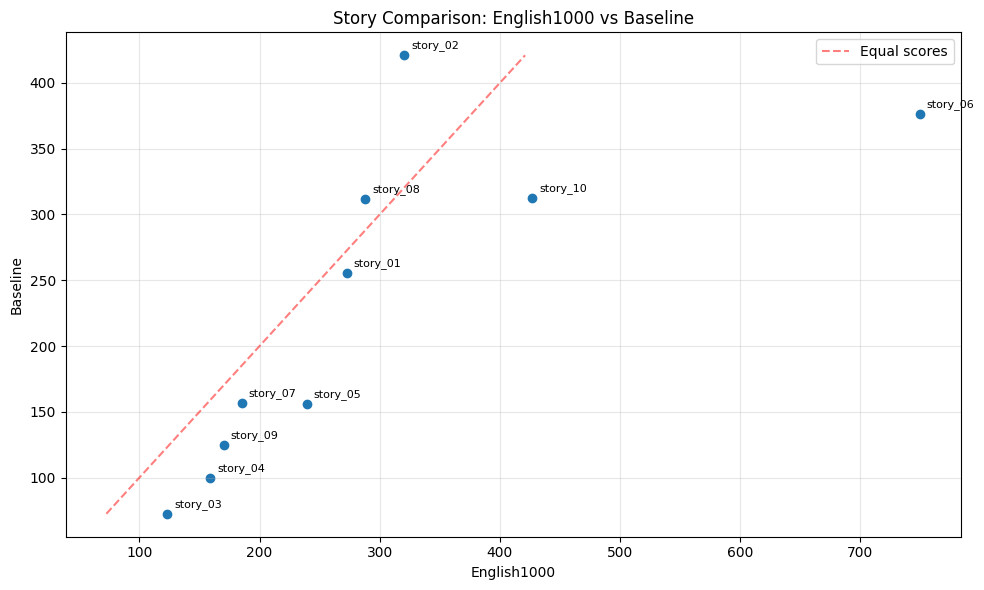

In [120]:
plt.figure(figsize=(10, 6))
plt.scatter(comparison['english1000'], comparison['baseline'])

for i, story in enumerate(comparison['story']):
    plt.annotate(story, (comparison['english1000'][i], comparison['baseline'][i]), 
                xytext=(5, 5), textcoords='offset points', fontsize=8)

plt.xlabel('English1000')
plt.ylabel('Baseline')
plt.title('Story Comparison: English1000 vs Baseline')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.plot([comparison['baseline'].min(), comparison['baseline'].max()], 
         [comparison['baseline'].min(), comparison['baseline'].max()], 
         'r--', alpha=0.5, label='Equal scores')
plt.legend()
plt.show()

In [112]:
# Calculate difference and identify outliers
comparison['difference'] = comparison['english1000'] - comparison['baseline']
comparison['abs_difference'] = comparison['difference'].abs()
comparison_sorted = comparison.sort_values('abs_difference', ascending=False)
print("Stories ranked by absolute difference:")
print(comparison_sorted[['story', 'english1000', 'baseline', 'difference']])

Stories ranked by absolute difference:
      story  english1000    baseline  difference
5  story_06   749.478516  376.371216  373.107300
9  story_10   434.168030  312.496826  121.671204
1  story_02   320.265686  420.990723 -100.725037
4  story_05   239.255096  155.827911   83.427185
3  story_04   158.733017   99.338547   59.394470
2  story_03   123.117035   72.476395   50.640640
8  story_09   170.168823  124.843849   45.324974
6  story_07   185.168823  156.732361   28.436462
7  story_08   287.764099  311.602112  -23.838013
0  story_01   272.487671  255.187820   17.299850


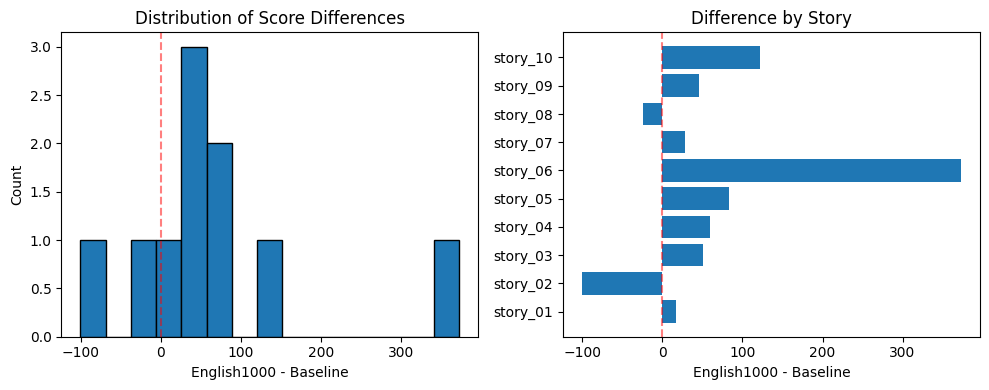

In [113]:
# Plot distribution of differences
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.hist(comparison['difference'], bins=15, edgecolor='black')
plt.xlabel('English1000 - Baseline')
plt.ylabel('Count')
plt.title('Distribution of Score Differences')
plt.axvline(0, color='red', linestyle='--', alpha=0.5)

plt.subplot(1, 2, 2)
plt.barh(comparison['story'], comparison['difference'])
plt.xlabel('English1000 - Baseline')
plt.title('Difference by Story')
plt.axvline(0, color='red', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [212]:
import re
from difflib import SequenceMatcher

def normalize_token(token):
    """Remove punctuation and convert to lowercase."""
    return re.sub(r'[^\w\s]', '', token.lower())

def align_tokens(ds_tokens, txt_tokens):
    """
    Align ds_tokens to txt_tokens, returning matched txt tokens for each ds token.
    
    Returns:
        ds_tokens_matched: list of matched txt_tokens (or None if no match found)
    """
    ds_tokens_matched = []
    txt_idx = 0
    
    for ds_idx, ds_token in enumerate(ds_tokens):
        ds_norm = normalize_token(ds_token)
        
        # Skip if we've exhausted txt_tokens
        if txt_idx >= len(txt_tokens):
            ds_tokens_matched.append(None)
            continue
        
        # Try exact match
        if ds_token == txt_tokens[txt_idx]:
            ds_tokens_matched.append(txt_tokens[txt_idx])
            txt_idx += 1
            continue
        
        # Try normalized match (case + punctuation)
        txt_norm = normalize_token(txt_tokens[txt_idx])
        if ds_norm == txt_norm:
            ds_tokens_matched.append(txt_tokens[txt_idx])
            txt_idx += 1
            continue
        
        # Look ahead in txt_tokens for a match (up to 5 tokens)
        found = False
        for lookahead in range(1, min(6, len(txt_tokens) - txt_idx)):
            candidate_norm = normalize_token(txt_tokens[txt_idx + lookahead])
            if ds_norm == candidate_norm:
                # Skip txt tokens that don't match (missing in ds)
                txt_idx += lookahead
                ds_tokens_matched.append(txt_tokens[txt_idx])
                txt_idx += 1
                found = True
                break
        
        if found:
            continue
        
        # Try fuzzy match with current position
        similarity = SequenceMatcher(None, ds_norm, txt_norm).ratio()
        if similarity > 0.8:
            ds_tokens_matched.append(txt_tokens[txt_idx])
            txt_idx += 1
        else:
            print(f"No match for ds token '{ds_token}' at index {ds_idx} (txt token '{txt_tokens[txt_idx]}')")
            ds_tokens_matched.append(ds_token)
    
    return ds_tokens_matched

# Usage for your investigation
story = 'story_06'
ds_tokens = [w for w in ds[story].data if w not in BAD_WORDS]
txt_tokens = [w for w in open(f"../data/stimuli/texts/{story}.txt").read().split() if w not in BAD_WORDS]

ds_tokens_matched = align_tokens(ds_tokens, txt_tokens)

# Create comparison DataFrame
alignment_df = pd.DataFrame({
    'ds_idx': range(len(ds_tokens)),
    'ds_token': ds_tokens,
    'txt_token_matched': ds_tokens_matched,
    'is_match': [m is not None for m in ds_tokens_matched],
})

alignment_df.to_csv(f"{story}_alignment_detailed.csv", index=False)
display(alignment_df)

# Summary
print(f"\nAlignment summary for {story}:")
print(f"Total ds tokens: {len(ds_tokens)}")
print(f"Matched tokens: {sum(m is not None for m in ds_tokens_matched)}")
print(f"Match rate: {sum(m is not None for m in ds_tokens_matched) / len(ds_tokens):.1%}")

No match for ds token 'dave' at index 47 (txt token 'David')
No match for ds token 'then' at index 50 (txt token 'I')
No match for ds token 'when' at index 51 (txt token 'I')
No match for ds token 'he' at index 213 (txt token 'He's')
No match for ds token 'was' at index 214 (txt token 'He's')
No match for ds token 'ya' at index 235 (txt token 'I')
No match for ds token 'know' at index 236 (txt token 'I')
No match for ds token ' ' at index 241 (txt token 'great')
No match for ds token 'ya' at index 324 (txt token 'my')
No match for ds token 'know' at index 325 (txt token 'my')
No match for ds token 'um' at index 623 (txt token 'I'll')
No match for ds token '{sp}' at index 798 (txt token 'to')
No match for ds token 'you ' at index 811 (txt token 'have')
No match for ds token 'know' at index 812 (txt token 'have')
No match for ds token 't' at index 998 (txt token 't-shirt')
No match for ds token 'black' at index 1018 (txt token 'shoe')
No match for ds token 'sneakers' at index 1019 (txt t

,ds_idx,ds_token,txt_token_matched,is_match
0,0,i,I,True
1,1,grew,grew,True
2,2,up,up,True
3,3,a,a,True
4,4,uh,uh,True
...,...,...,...,...
2781,2781,it,it,True
2782,2782,into,into,True
2783,2783,being,being.,True
2784,2784,thank,Thank,True



Alignment summary for story_06:
Total ds tokens: 2786
Matched tokens: 2786
Match rate: 100.0%


In [213]:
from data_loading import DataSequence, ContextManager, EmbeddingManager

In [219]:
ds_new = DataSequence(ds_tokens_matched, ds[story].split_inds, ds[story].data_times, ds[story].tr_times)
ctx_mgr = ContextManager(os.path.join('..',config.DEFAULT_CONTEXTS_FILE))
emb_mgr = EmbeddingManager(os.path.join('..',config.DEFAULT_EMBEDDINGS_FILE))

In [221]:
contexts = ctx_mgr.get_or_create_contexts('peak', ['story_06'], { 'story_06': ds_new }, overwrite=True)

Generating peak contexts for story: story_06:   0%|          | 0/2786 [00:00<?, ?it/s]

Generating peak contexts for story: story_06:   2%|▏         | 65/2786 [01:28<1:01:31,  1.36s/it]


KeyboardInterrupt: 

In [210]:
emb_mgr.get_or_create_embeddings('baseline', ['story_06'], { 'story_06': ds_new }, contexts, overwrite=True, verbose=True)


--- Model Setup ---
Device: cuda
Model: openai-community/gpt2
Layer: 8
-------------------
Total input words: 3102


Generating gpt2 embeddings for story_06:   0%|          | 14/3102 [00:00<00:22, 135.97it/s]


Processing word index 0: I
Context: I
Tokenized context: ['I']
Target word start index: 0
Word-level mask indices: []
Shape of layer embedding: torch.Size([1, 768])
Shape of word vector sequence: torch.Size([1, 768])
Selected word embedding shape: (768,)
Applied z-score normalization to the embedding.

Processing word index 1: grew
Context: I grew
Tokenized context: ['I', 'Ġgrew']
Target word start index: 1
Word-level mask indices: []
Shape of layer embedding: torch.Size([2, 768])
Shape of word vector sequence: torch.Size([1, 768])
Selected word embedding shape: (768,)
Applied z-score normalization to the embedding.

Processing word index 2: up
Context: I grew up
Tokenized context: ['I', 'Ġgrew', 'Ġup']
Target word start index: 2
Word-level mask indices: []
Shape of layer embedding: torch.Size([3, 768])
Shape of word vector sequence: torch.Size([1, 768])
Selected word embedding shape: (768,)
Applied z-score normalization to the embedding.

Processing word index 3: a
Context: I grew up

Generating gpt2 embeddings for story_06:   1%|▏         | 42/3102 [00:00<00:22, 134.86it/s]

Tokenized context: ['was', 'Ġvery', 'Ġsmall', 'Ġinvolved', 'Ġgoing', 'Ġto', 'Ġgames', '.', 'Ġmaybe', 'Ġonce', 'Ġa', 'Ġyear']
Target word start index: 11
Word-level mask indices: []
Shape of layer embedding: torch.Size([12, 768])
Shape of word vector sequence: torch.Size([1, 768])
Selected word embedding shape: (768,)
Applied z-score normalization to the embedding.

Processing word index 28: with
Context: very small involved going to games. maybe once a year with
Tokenized context: ['very', 'Ġsmall', 'Ġinvolved', 'Ġgoing', 'Ġto', 'Ġgames', '.', 'Ġmaybe', 'Ġonce', 'Ġa', 'Ġyear', 'Ġwith']
Target word start index: 11
Word-level mask indices: []
Shape of layer embedding: torch.Size([12, 768])
Shape of word vector sequence: torch.Size([1, 768])
Selected word embedding shape: (768,)
Applied z-score normalization to the embedding.

Processing word index 29: my
Context: small involved going to games. maybe once a year with my
Tokenized context: ['small', 'Ġinvolved', 'Ġgoing', 'Ġto', 'Ġgames', 

Generating gpt2 embeddings for story_06: 100%|██████████| 3102/3102 [00:22<00:00, 140.12it/s]


Doing lanczos interpolation with cutoff=0.499 and 3 lobes.


ValueError: shapes (373,2786) and (3102,768) not aligned: 2786 (dim 1) != 3102 (dim 0)

In [201]:
loaded_contexts = ctx_mgr.get_or_create_contexts('baseline', ['story_06'], { 'story_06': ds_new }, overwrite=False)

In [204]:
loaded_embeddings = emb_mgr.get_or_create_embeddings('baseline', ['story_06'], { 'story_06': ds_new }, loaded_contexts, overwrite=False, verbose=True)

In [170]:
story = story_to_investigate
ds_tokens = [w for w in ds[story].data if w not in BAD_WORDS]
txt_tokens = [w for w in open(f"../data/stimuli/texts/{story}.txt").read().split() if w not in BAD_WORDS]

is_equal = [ds_tokens[i].upper() == txt_tokens[i].upper() for i in range(min(len(ds_tokens), len(txt_tokens)))]

n = min(len(ds_tokens), len(txt_tokens))
alignment_df = pd.DataFrame({
    "index": range(n),
    "ds_token": ds_tokens[:n],
    "txt_token": txt_tokens[:n],
    "is_equal": is_equal[:n],
})
alignment_df.to_csv(f"{story}_alignment.csv", index=False)
alignment_df

,index,ds_token,txt_token,is_equal
0,0,i,I,True
1,1,grew,grew,True
2,2,up,up,True
3,3,a,a,True
4,4,uh,uh,True
...,...,...,...,...
2777,2777,you,it,False
2778,2778,can,into,False
2779,2779,sometimes,being.,False
2780,2780,will,Thank,False


In [140]:
# Correlate differences with candidate story-level factors
factors_df = pd.DataFrame({
    'story': config.STORIES,
    'tr_count': [len(tr[s].trtimes) for s in config.STORIES],
    'tg_duration': [tg[s][-1][1] for s in config.STORIES],
    'word_count': [len(" ".join(ds[s].data).split()) for s in config.STORIES],
    'similarity': [
        sum(
            1
            for word in " ".join(ds[s].data).split()
            if word in " ".join(
                [
                    w
                    for w in open(f"../data/stimuli/texts/{s}.txt").read().split()
                    if w not in BAD_WORDS
                ]
            ).split()
        )
        / len(" ".join(ds[s].data).split())
        for s in config.STORIES
    ],
})
# factors_df = factors_df[factors_df['story'] != 'story_06'].reset_index(drop=True)
factors_df

,story,tr_count,tg_duration,word_count,similarity
0,story_01,358,706.686395,2174,0.848666
1,story_02,382,754.248300,1463,0.828435
2,story_03,369,728.267347,1964,0.865580
3,story_04,415,819.988889,1892,0.893235
4,story_05,445,880.266062,2211,0.899141
5,story_06,373,736.877777,2785,0.865350
6,story_07,437,865.036508,3219,0.929481
7,story_08,419,828.100454,2669,0.842263
8,story_09,370,729.993424,1867,0.866095
9,story_10,319,627.745805,1641,0.882389


In [ ]:
# Compare ds tokens vs text file tokens per story
from collections import Counter
def get_tokens(story):
    ds_tokens = [w.lower() for w in " ".join(ds[story].data).split() if w not in BAD_WORDS]
    txt_tokens = [
        w.lower()
        for w in open(f"../data/stimuli/texts/{story}.txt").read().split()
        if w not in BAD_WORDS
    ]
    return ds_tokens, txt_tokens

summary_rows = []
for story in config.STORIES:
    ds_tokens, txt_tokens = get_tokens(story)
    set_ds, set_txt = set(ds_tokens), set(txt_tokens)
    inter = set_ds & set_txt
    union = set_ds | set_txt
    summary_rows.append({
        'story': story,
        'ds_tokens': len(ds_tokens),
        'txt_tokens': len(txt_tokens),
        'overlap_tokens': len(inter),
        'jaccard': len(inter) / len(union) if union else np.nan,
        'ds_only_tokens': len(set_ds - set_txt),
        'txt_only_tokens': len(set_txt - set_ds),
    })
token_summary = pd.DataFrame(summary_rows).sort_values('jaccard')
display(token_summary)

# Inspect token differences for worst-overlap stories and worst score differences
worst_overlap = token_summary.nsmallest(3, 'jaccard')['story'].values
worst_scores = comparison_sorted.head(3)['story'].values
focus_stories = pd.unique(np.concatenate([worst_overlap, worst_scores]))
for story in focus_stories:
    ds_tokens, txt_tokens = get_tokens(story)
    ds_counts, txt_counts = Counter(ds_tokens), Counter(txt_tokens)
    ds_only_common = (ds_counts - txt_counts).most_common(10)
    txt_only_common = (txt_counts - ds_counts).most_common(10)
    jacc = token_summary.loc[token_summary['story'] == story, 'jaccard'].values[0]
    print(f"\n{story} (Jaccard: {jacc:.3f})")
    print("  In ds only (top 10):", ds_only_common)
    print("  In txt only (top 10):", txt_only_common)

,story,ds_tokens,txt_tokens,overlap_tokens,jaccard,ds_only_tokens,txt_only_tokens
1,story_02,1463,1464,376,0.557037,94,205
7,story_08,2669,2646,483,0.575685,108,248
10,story_11,1838,1845,437,0.578808,84,234
0,story_01,2174,2192,519,0.606308,103,234
4,story_05,2211,2217,456,0.620408,79,200
6,story_07,3219,3208,660,0.632184,106,278
2,story_03,1964,1965,501,0.645619,84,191
3,story_04,1892,1898,428,0.657450,72,151
9,story_10,1641,1645,526,0.666667,88,175
8,story_09,1867,1881,502,0.673826,77,166



story_02 (Jaccard: 0.557)
  In ds only (top 10): [('me', 7), ('stories', 6), ('know', 6), ('this', 5), ('tell', 4), ('movie', 4), ('before', 4), ('that', 4), ('way', 4), ('sarah', 3)]
  In txt only (top 10): [('movie,', 4), ('me,', 4), ('avatar.', 3), ('parent,', 3), ('know.', 3), ('know,', 3), ('stories,', 3), ('me.', 3), ('way.', 3), ('this.', 3)]

story_08 (Jaccard: 0.576)
  In ds only (top 10): [('know', 31), ('like', 21), ('it', 12), ('alright', 11), ('and', 10), ('football', 9), ('uh', 8), ('i', 8), ('me', 8), ('m', 7)]
  In txt only (top 10): [('like,', 24), ('know,', 16), ('know.', 9), ('.', 7), ('me,', 7), ('it.', 7), ('m.', 6), ('uh,', 6), ('g.', 5), ('cool.', 5)]

story_11 (Jaccard: 0.579)
  In ds only (top 10): [('says', 11), ('you', 10), ('oh', 7), ('yeah', 6), ('ok', 5), ('cigarettes', 5), ('that', 5), ('there', 5), ('me', 5), ('home', 5)]
  In txt only (top 10): [('says,', 10), ('"you', 7), ('say,', 4), ('cigarettes.', 3), ('"i', 3), ('again,', 3), ('like,', 3), ('"oh,'

In [146]:
token_summary.sort_values('story')['jaccard']

,story,tr_count,tg_duration,word_count,similarity,jaccard
0,story_01,358,706.686395,2174,0.848666,0.606308
1,story_02,382,754.248300,1463,0.828435,0.557037
2,story_03,369,728.267347,1964,0.865580,0.645619
3,story_04,415,819.988889,1892,0.893235,0.657450
4,story_05,445,880.266062,2211,0.899141,0.620408
5,story_06,373,736.877777,2785,0.865350,0.691854
6,story_07,437,865.036508,3219,0.929481,0.632184
7,story_08,419,828.100454,2669,0.842263,0.575685
8,story_09,370,729.993424,1867,0.866095,0.673826
9,story_10,319,627.745805,1641,0.882389,0.666667


In [149]:
comparison_factors = comparison.merge(factors_df, on='story', how='left')
factors = ['tr_count', 'tg_duration', 'word_count', 'similarity', 'jaccard']
comparison_factors = comparison.merge(factors_df, on='story', how='left')
factors = ['tr_count', 'tg_duration', 'word_count', 'similarity', 'jaccard']
comparison_factors['difference'] = comparison_factors['english1000'] - comparison_factors['baseline']
comparison_factors[['difference'] + factors].corr()['difference'].drop('difference')

tr_count      -0.197359
tg_duration   -0.195459
word_count     0.341867
similarity     0.238525
jaccard        0.775938
Name: difference, dtype: float64

Correlation with English1000 - Baseline:
jaccard        0.775938
word_count     0.341867
similarity     0.238525
tg_duration   -0.195459
tr_count      -0.197359
Name: difference, dtype: float64


Correlation with English1000 - Baseline:
jaccard        0.775938
word_count     0.341867
similarity     0.238525
tg_duration   -0.195459
tr_count      -0.197359
Name: difference, dtype: float64


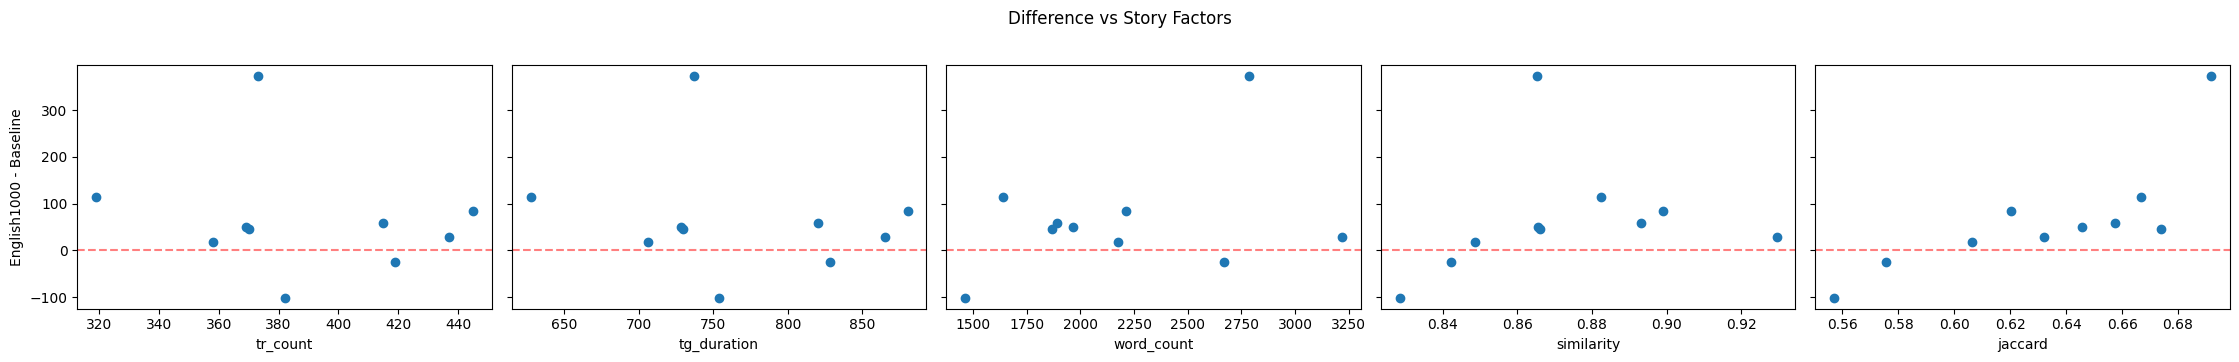

In [150]:
corrs = comparison_factors[['difference'] + factors].corr()['difference'].drop('difference')
print("Correlation with English1000 - Baseline:")
print(corrs.sort_values(ascending=False))
fig, axes = plt.subplots(1, len(factors), figsize=(4.5 * len(factors), 3.5), sharey=True)
for ax, factor in zip(axes, factors):
    ax.scatter(comparison_factors[factor], comparison_factors['difference'])
    ax.set_xlabel(factor)
    ax.axhline(0, color='red', linestyle='--', alpha=0.5)
axes[0].set_ylabel('English1000 - Baseline')
fig.suptitle('Difference vs Story Factors', y=1.02)
fig.tight_layout()
plt.show()

In [114]:
# Examine top discrepancy stories in detail
top_discrepancies = comparison_sorted.head(3)['story'].values
print(f"Investigating top discrepancy stories: {top_discrepancies}")

for story in top_discrepancies:
    print(f"\n{story}:")
    print(f"  English1000 score: {comparison[comparison['story']==story]['english1000'].values[0]:.2f}")
    print(f"  Baseline score: {comparison[comparison['story']==story]['baseline'].values[0]:.2f}")
    print(f"  Difference: {comparison[comparison['story']==story]['difference'].values[0]:.2f}")

Investigating top discrepancy stories: ['story_06' 'story_10' 'story_02']

story_06:
  English1000 score: 749.48
  Baseline score: 376.37
  Difference: 373.11

story_10:
  English1000 score: 434.17
  Baseline score: 312.50
  Difference: 121.67

story_02:
  English1000 score: 320.27
  Baseline score: 420.99
  Difference: -100.73
